<a href="https://colab.research.google.com/github/RogerVin1/Assigment1-DeepLearnig/blob/main/assigment1DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 0

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.draw import ellipse
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from scipy import ndimage

Objetos por imagem (200 amostras): min=5, media=12.5, max=20


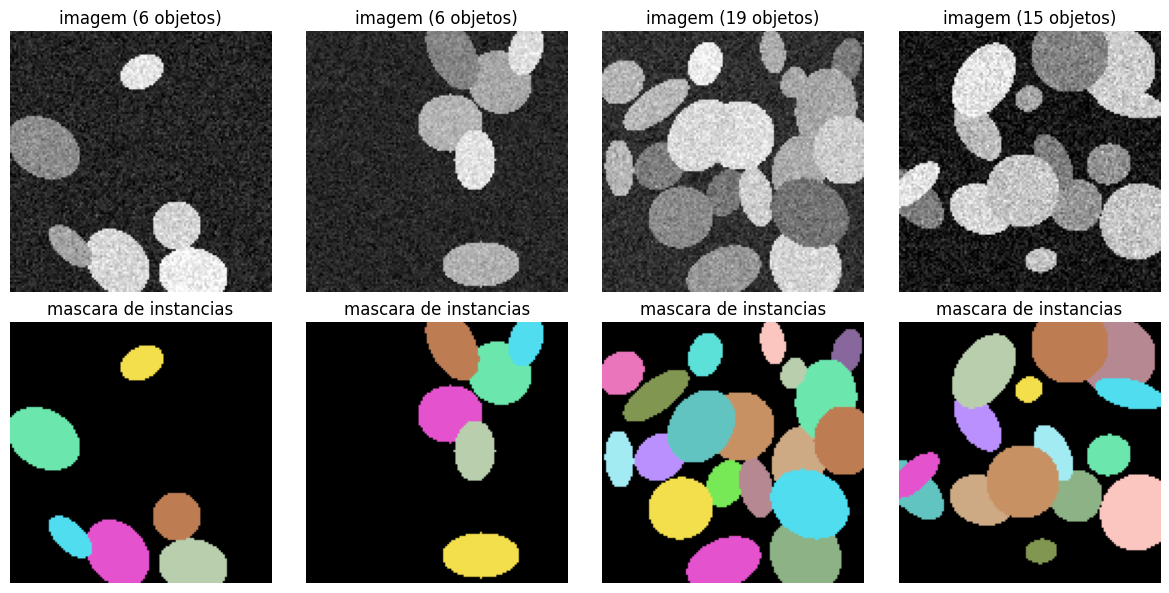

In [3]:
# Desenhar uma elipse como uma mascara booleana
def _mascara_de_uma_elipse(size, cy, cx, ry, rx, angulo):
    """
    Retorna um array booleano (size x size) com True dentro da elipse
    """

    mask = np.zeros((size, size), dtype=bool)
    rr, cc = ellipse(cy, cx, ry, rx, shape=(size, size), rotation=angulo)
    mask[rr, cc] = True
    return mask

# Gerar uma amostra
def gerar_amostra(size=128,
                  min_elipses=5,
                  max_elipses=20,
                  raio_min=6,
                  raio_max=20,
                  taxa_min_manter=0.55,
                  rng=None):
    """
    Gera uma imagem sintetica e sua mascara de instancias
    """
    if rng is None:
        rng = np.random.default_rng()

    # guarda o ID da instancia de cada pixel
    inst_mask = np.zeros((size, size), dtype=np.int32)
    proximo_id = 1

    n_elipses = int(rng.integers(min_elipses, max_elipses + 1))

    colocadas = 0
    max_tentativas = n_elipses * 12
    tentativas = 0

    while colocadas < n_elipses and tentativas < max_tentativas:
        tentativas += 1

        # sorteia a geometria da elipse
        cy = rng.integers(raio_min, size - raio_min)
        cx = rng.integers(raio_min, size - raio_min)
        ry = rng.integers(raio_min, raio_max + 1)
        rx = rng.integers(raio_min, raio_max + 1)
        angulo = rng.uniform(0, np.pi)

        cand = _mascara_de_uma_elipse(size, cy, cx, ry, rx, angulo)
        area_total = cand.sum()
        if area_total == 0:
            continue

        # so ficamos com os pixels que AINDA sao fundo
        livre = cand & (inst_mask == 0)
        if livre.sum() / area_total < taxa_min_manter:
            # sobrou pouco desta elipse então descarta e tenta outra posicao
            continue

        inst_mask[livre] = proximo_id
        proximo_id += 1
        colocadas += 1

    # constrói a imagem em tons de cinza a partir das instâncias
    image = _renderizar_imagem(inst_mask, rng)

    return image, inst_mask

# Transformar a mascara de instancias numa imagem "de microscopia"
def _renderizar_imagem(inst_mask, rng):
    """
    Pinta cada instancia com um tom de cinza proprio (contraste variavel entre
    objetos), coloca um fundo escuro variavel, e adiciona ruido gaussiano.
    """
    size = inst_mask.shape[0]

    # fundo escuro, com nivel variando de imagem para imagem (contraste global)
    nivel_fundo = rng.uniform(0.05, 0.20)
    image = np.full((size, size), nivel_fundo, dtype=np.float32)

    # cada instancia recebe um brilho proprio
    ids = np.unique(inst_mask)
    ids = ids[ids != 0]

    for i in ids:
        brilho = rng.uniform(0.45, 0.95)
        image[inst_mask == i] = brilho

    # ruido gaussiano
    sigma = rng.uniform(0.02, 0.12)
    image = image + rng.normal(0, sigma, size=image.shape)

    # mantem tudo no intervalo valido [0, 1]
    image = np.clip(image, 0.0, 1.0).astype(np.float32)

    return image

# Utilitario: colorir a mascara de instancias (so para visualizar)
def colorir_instancias(inst_mask, rng=None):
    """
    Devolve uma imagem RGB (size, size, 3) onde cada instancia tem uma cor
    aleatoria distinta e o fundo e preto. Serve so para inspecao visual.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    size = inst_mask.shape[0]
    rgb = np.zeros((size, size, 3), dtype=np.float32)
    ids = np.unique(inst_mask)
    ids = ids[ids != 0]

    for i in ids:
        cor = rng.uniform(0.3, 1.0, size=3)
        rgb[inst_mask == i] = cor

    return rgb

if __name__ == "__main__":

    rng = np.random.default_rng(42)

    n_mostrar = 4
    fig, axes = plt.subplots(2, n_mostrar, figsize=(3 * n_mostrar, 6))

    for col in range(n_mostrar):
        image, inst_mask = gerar_amostra(rng=rng)
        n_obj = len(np.unique(inst_mask)) - 1

        axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"imagem ({n_obj} objetos)")
        axes[0, col].axis("off")

        axes[1, col].imshow(colorir_instancias(inst_mask))
        axes[1, col].set_title("mascara de instancias")
        axes[1, col].axis("off")

    plt.tight_layout()

    contagens = []
    r2 = np.random.default_rng(0)
    for _ in range(200):
        _, m = gerar_amostra(rng=r2)
        contagens.append(len(np.unique(m)) - 1)
    contagens = np.array(contagens)
    print(f"Objetos por imagem (200 amostras): "
          f"min={contagens.min()}, media={contagens.mean():.1f}, max={contagens.max()}")

In [4]:
class DadosSinteticos(Dataset):
    """Pega o nosso gerador e devolve pares (imagem, máscara binária)."""
    def __init__(self, n_amostras, seed):
        self.amostras = []
        rng = np.random.default_rng(seed)

        for _ in range(n_amostras):
            image, inst_mask = gerar_amostra(rng=rng)
            # é binário: 1 = tem objeto, 0 = fundo
            bin_mask = (inst_mask > 0).astype(np.float32)
            self.amostras.append((image, bin_mask))

    def __len__(self):
        return len(self.amostras)

    def __getitem__(self, idx):
        image, bin_mask = self.amostras[idx]
        # a rede espera formato (canais, altura, largura) e nossa imagem tem 1 canal que é cinza

        # vira (1, 128, 128)
        x = torch.from_numpy(image).unsqueeze(0)
        y = torch.from_numpy(bin_mask).unsqueeze(0)
        return x, y

In [5]:
def bloco_conv(c_in, c_out):
    """Duas convoluções seguidas"""

    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
    )

class UNetPequena(nn.Module):

    def __init__(self):
        super().__init__()
        self.enc1 = bloco_conv(1, 16)
        self.enc2 = bloco_conv(16, 32)

        # reduz a imagem pela metade
        self.pool = nn.MaxPool2d(2)
        self.meio = bloco_conv(32, 64)
        self.up2  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = bloco_conv(64, 32)
        self.up1  = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = bloco_conv(32, 16)
        self.saida = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        m  = self.meio(self.pool(e2))
        d2 = self.dec2(torch.cat([self.up2(m),  e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.saida(d1)

In [6]:
def dice_iou(logits, alvo, limiar=0.5):
    """Duas formas de medir 'o quanto a previsão bate com o gabarito' (0 a 1, maior é melhor)"""
    pred = (torch.sigmoid(logits) > limiar).float()
    inter = (pred * alvo).sum(dim=(1,2,3))
    soma  = pred.sum(dim=(1,2,3)) + alvo.sum(dim=(1,2,3))
    dice = ((2*inter + 1e-6) / (soma + 1e-6)).mean().item()
    iou  = ((inter + 1e-6) / (soma - inter + 1e-6)).mean().item()
    return dice, iou

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

treino = DadosSinteticos(n_amostras=200, seed=1)
val = DadosSinteticos(n_amostras=40, seed=2)
carr_treino = DataLoader(treino, batch_size=8, shuffle=True)
carr_val = DataLoader(val, batch_size=8)

modelo = UNetPequena().to(device)
criterio = nn.BCEWithLogitsLoss()
otim = torch.optim.Adam(modelo.parameters(), lr=1e-3)

for epoca in range(12):
    modelo.train()

    for x, y in carr_treino:
        x, y = x.to(device), y.to(device)
        otim.zero_grad()

        # mede o erro
        perda = criterio(modelo(x), y)

        # descobre como corrigir
        perda.backward()

        # corrige uma parte
        otim.step()

    modelo.eval()
    ds, val_is = [], []
    with torch.no_grad():
        for x, y in carr_val:
            x, y = x.to(device), y.to(device)
            d, i = dice_iou(modelo(x), y); ds.append(d); val_is.append(i)
    print(f"época {epoca+1:2d} | perda {perda.item():.3f} | val Dice {np.mean(ds):.3f} | val IoU {np.mean(val_is):.3f}")


época  1 | perda 0.352 | val Dice 0.938 | val IoU 0.885
época  2 | perda 0.277 | val Dice 0.987 | val IoU 0.975
época  3 | perda 0.229 | val Dice 0.994 | val IoU 0.989
época  4 | perda 0.186 | val Dice 0.997 | val IoU 0.994
época  5 | perda 0.139 | val Dice 0.998 | val IoU 0.996
época  6 | perda 0.123 | val Dice 0.999 | val IoU 0.998
época  7 | perda 0.114 | val Dice 0.998 | val IoU 0.995
época  8 | perda 0.079 | val Dice 0.999 | val IoU 0.999
época  9 | perda 0.064 | val Dice 0.999 | val IoU 0.999
época 10 | perda 0.051 | val Dice 0.999 | val IoU 0.999
época 11 | perda 0.043 | val Dice 1.000 | val IoU 0.999
época 12 | perda 0.037 | val Dice 1.000 | val IoU 0.999


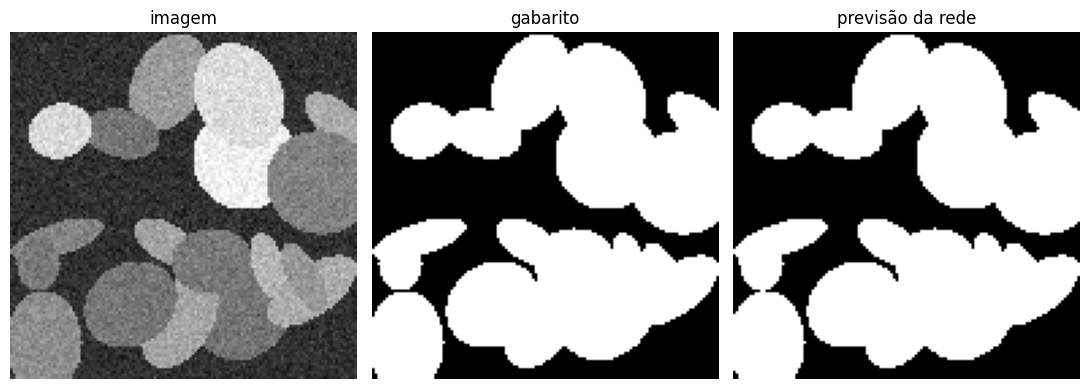

In [7]:
modelo.eval()
x, y = val[0]

with torch.no_grad():
    prob = torch.sigmoid(modelo(x.unsqueeze(0).to(device)))[0,0].cpu().numpy()

pred = (prob > 0.5).astype(float)

fig, ax = plt.subplots(1, 3, figsize=(11,4))
ax[0].imshow(x[0], cmap="gray"); ax[0].set_title("imagem"); ax[0].axis("off")
ax[1].imshow(y[0], cmap="gray"); ax[1].set_title("gabarito"); ax[1].axis("off")
ax[2].imshow(pred, cmap="gray"); ax[2].set_title("previsão da rede"); ax[2].axis("off")

plt.tight_layout()
plt.show()

## Parte 1

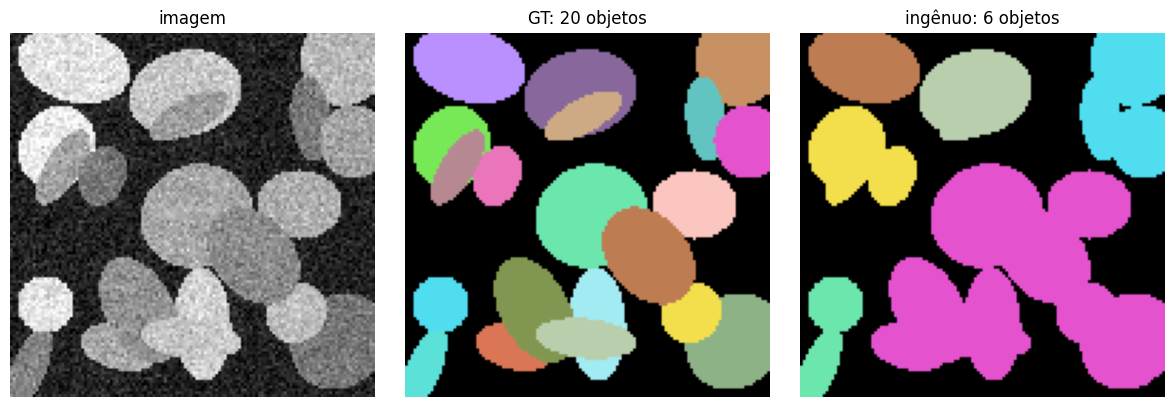

In [8]:
def instancias_ingenuas(prob, limiar=0.5):
    """Método ingênuo: binariza e rotula cada MANCHA CONEXA como um objeto."""
    binaria = prob > limiar
    rotulos, n = ndimage.label(binaria)
    return rotulos.astype(np.int32)

# roda numa imagem e compara GT com ingênuo
modelo.eval()
rng_demo = np.random.default_rng(7)
image, gt_labels = gerar_amostra(rng=rng_demo)
x = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    prob = torch.sigmoid(modelo(x))[0, 0].cpu().numpy()

pred_labels = instancias_ingenuas(prob, 0.5)

n_gt   = len(np.unique(gt_labels)) - 1
n_pred = len(np.unique(pred_labels)) - 1

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("imagem")
ax[0].axis("off")
ax[1].imshow(colorir_instancias(gt_labels))
ax[1].set_title(f"GT: {n_gt} objetos")
ax[1].axis("off")
ax[2].imshow(colorir_instancias(pred_labels))
ax[2].set_title(f"ingênuo: {n_pred} objetos")
ax[2].axis("off")
plt.tight_layout()
plt.show()

In [10]:
def matriz_iou(pred_labels, gt_labels):
    """IoU entre cada objeto previsto e cada objeto verdadeiro."""

    ids_pred = np.unique(pred_labels); ids_pred = ids_pred[ids_pred != 0]
    ids_gt   = np.unique(gt_labels);   ids_gt   = ids_gt[ids_gt != 0]
    iou = np.zeros((len(ids_pred), len(ids_gt)), dtype=np.float32)

    if len(ids_pred) == 0 or len(ids_gt) == 0:
        return iou, ids_pred, ids_gt

    area_pred = {i: int((pred_labels == i).sum()) for i in ids_pred}
    area_gt   = {j: int((gt_labels == j).sum())   for j in ids_gt}
    col_de = {j: c for c, j in enumerate(ids_gt)}

    for a, i in enumerate(ids_pred):
        mask_i = (pred_labels == i)
        vizinhos = np.unique(gt_labels[mask_i]); vizinhos = vizinhos[vizinhos != 0]

        for j in vizinhos:
            inter = int(np.logical_and(mask_i, gt_labels == j).sum())
            union = area_pred[i] + area_gt[j] - inter
            iou[a, col_de[j]] = inter / union

    return iou, ids_pred, ids_gt

def matching_guloso(iou, t):
    """Casa pares de maior IoU primeiro; cada objeto usado no máximo uma vez."""

    n_pred, n_gt = iou.shape
    pares = [(iou[i, j], i, j) for i in range(n_pred) for j in range(n_gt) if iou[i, j] >= t]
    # maior IoU primeiro
    pares.sort(reverse=True)
    usados_pred, usados_gt, tp = set(), set(), 0

    for v, i, j in pares:
        if i not in usados_pred and j not in usados_gt:
            usados_pred.add(i); usados_gt.add(j); tp += 1

    # previstos que sobraram
    fp = n_pred - len(usados_pred)

    # verdadeiros que ninguém achou
    fn = n_gt - len(usados_gt)

    return tp, fp, fn

In [11]:
def avaliar_instancias(modelo, device, n_imagens=50, seed=3):
    modelo.eval()
    rng = np.random.default_rng(seed)
    limiares = np.arange(0.5, 1.0, 0.05)
    ap_por_limiar = np.zeros(len(limiares))
    densidades, maps_img, erros = [], [], []

    for _ in range(n_imagens):
        image, gt_labels = gerar_amostra(rng=rng)
        x = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(modelo(x))[0, 0].cpu().numpy()

        pred_labels = instancias_ingenuas(prob, 0.5)

        iou, ids_pred, ids_gt = matriz_iou(pred_labels, gt_labels)
        aps = []

        for t in limiares:
            tp, fp, fn = matching_guloso(iou, t)
            aps.append(tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0)

        aps = np.array(aps)
        ap_por_limiar += aps
        maps_img.append(aps.mean())
        densidades.append(len(ids_gt))
        erros.append(abs(len(ids_pred) - len(ids_gt)))

    ap_por_limiar /= n_imagens

    return {"limiares": limiares, "ap_por_limiar": ap_por_limiar,
            "mAP": float(np.mean(maps_img)), "densidades": np.array(densidades),
            "maps_img": np.array(maps_img), "erros": np.array(erros),
            "erro_contagem_medio": float(np.mean(erros))}

res = avaliar_instancias(modelo, device, n_imagens=50, seed=3)
print(f"mAP (média de IoU 0.50 a 0.95): {res['mAP']:.3f}")
print(f"Erro absoluto de contagem por imagem (média): {res['erro_contagem_medio']:.2f}\n")
print("AP por limiar de IoU:")

for t, ap in zip(res["limiares"], res["ap_por_limiar"]):
    print(f"IoU >= {t:.2f}:  AP = {ap:.3f}")

mAP (média de IoU 0.50 a 0.95): 0.288
Erro absoluto de contagem por imagem (média): 7.42

AP por limiar de IoU:
IoU >= 0.50:  AP = 0.368
IoU >= 0.55:  AP = 0.339
IoU >= 0.60:  AP = 0.311
IoU >= 0.65:  AP = 0.291
IoU >= 0.70:  AP = 0.281
IoU >= 0.75:  AP = 0.267
IoU >= 0.80:  AP = 0.255
IoU >= 0.85:  AP = 0.255
IoU >= 0.90:  AP = 0.254
IoU >= 0.95:  AP = 0.254


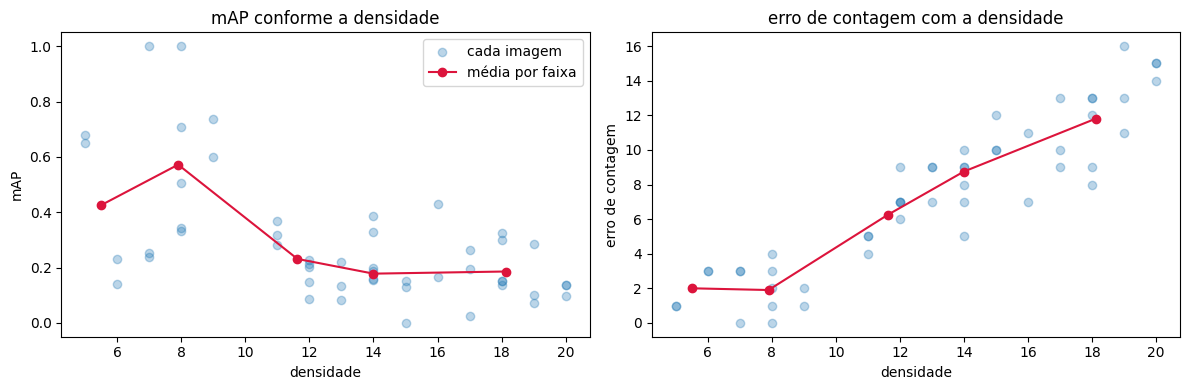

In [13]:
dens, maps, erros = res["densidades"], res["maps_img"], res["erros"]

# agrupa por faixa de densidade e tira a média em cada faixa
faixas = [(0, 7), (7, 10), (10, 13), (13, 16), (16, 99)]

centros = []
map_medio = []
erro_medio = []

for lo, hi in faixas:
    sel = (dens >= lo) & (dens < hi)

    if sel.sum() > 0:
        centros.append(dens[sel].mean())
        map_medio.append(maps[sel].mean())
        erro_medio.append(erros[sel].mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(dens, maps, alpha=0.3, label="cada imagem")
ax[0].plot(centros, map_medio, "-o", color="crimson", label="média por faixa")
ax[0].set_xlabel("densidade")
ax[0].set_ylabel("mAP")
ax[0].legend()
ax[0].set_title("mAP conforme a densidade")

ax[1].scatter(dens, erros, alpha=0.3)
ax[1].plot(centros, erro_medio, "-o", color="crimson")
ax[1].set_xlabel("densidade")
ax[1].set_ylabel("erro de contagem")
ax[1].set_title("erro de contagem com a densidade")
plt.tight_layout()
plt.show()